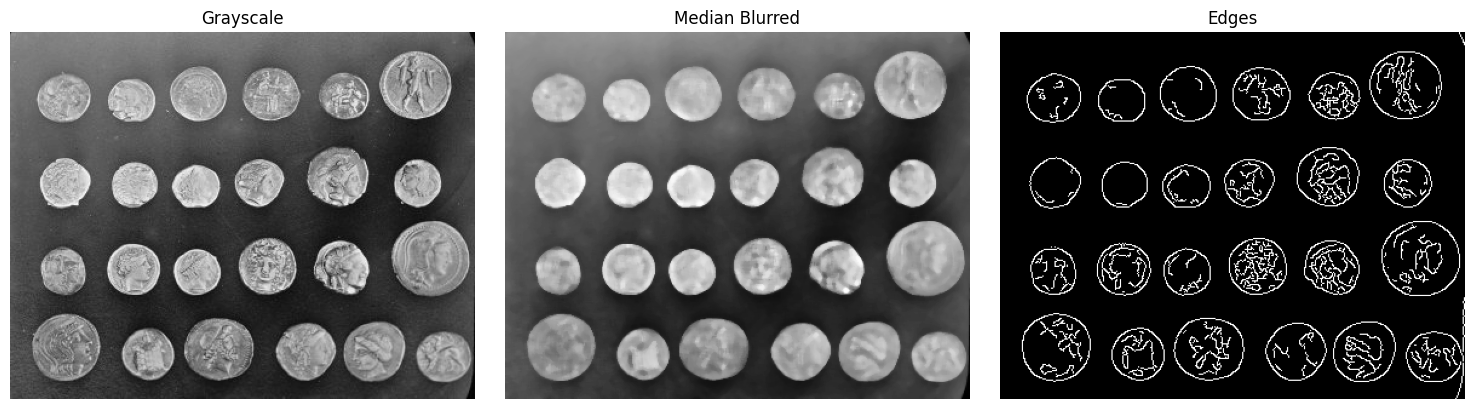

Total coins: 24


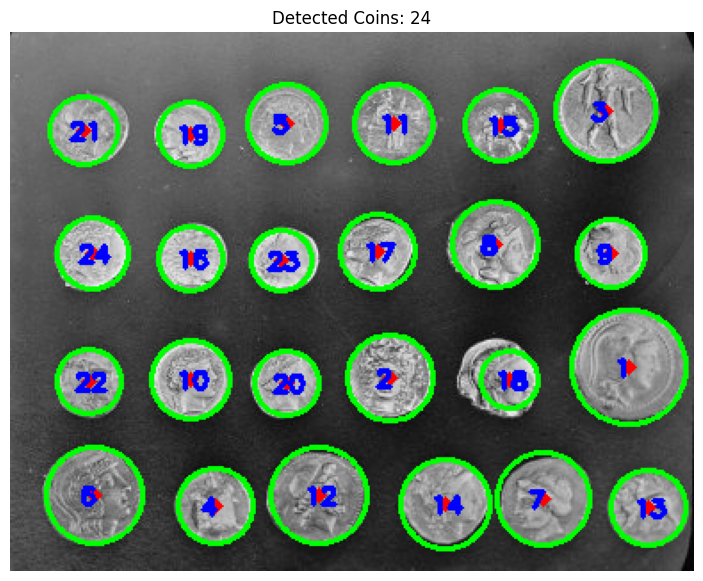

Small coins: 16
Big coins: 8


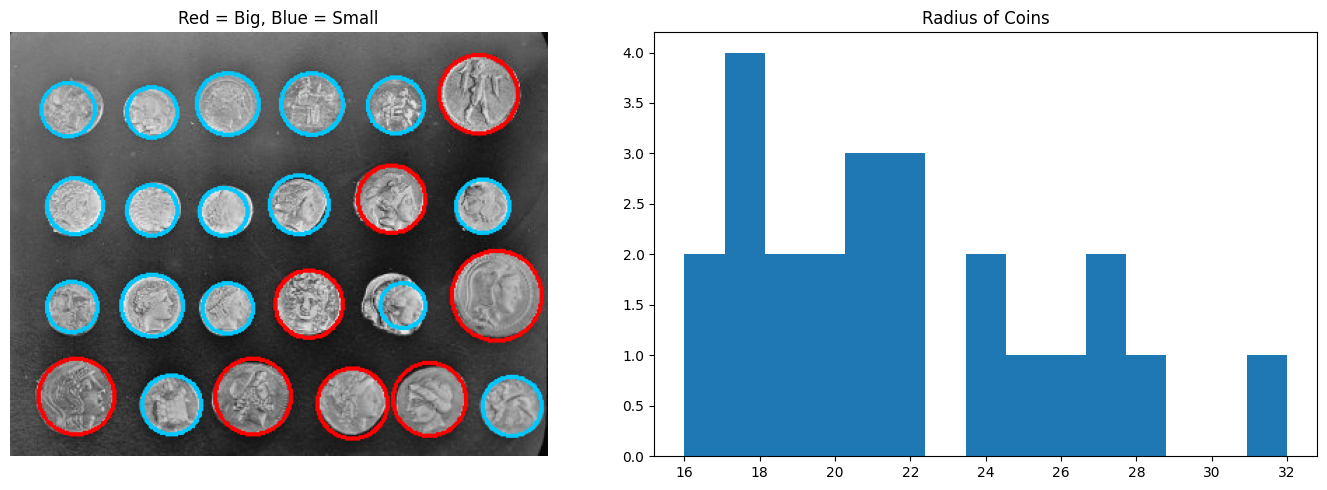

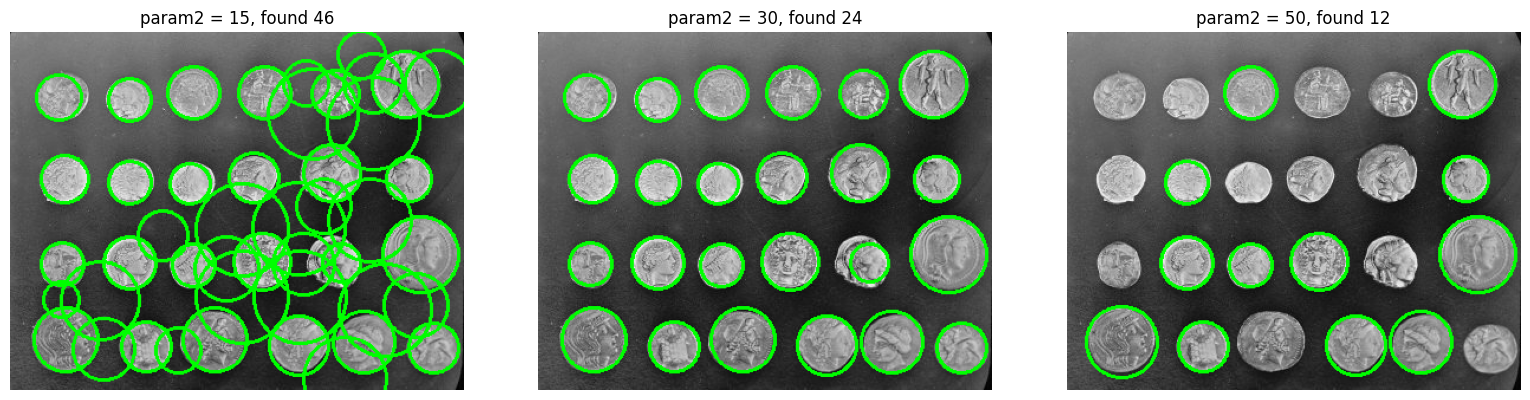

Total in second image: 12


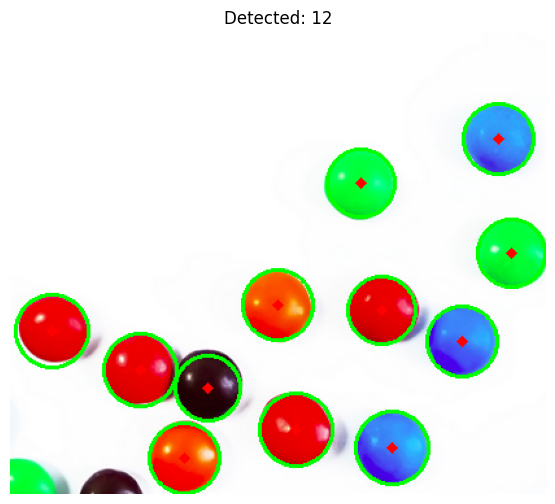

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("coins.png")
if image is None:
    print("Image not found, check the path")

# Convert BGR to RGB for Matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Median blur (removes the design inside the coins)
blurred = cv2.medianBlur(gray, 5)

# Canny edges (just to see the edges)
edges = cv2.Canny(blurred, 50, 100)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(blurred, cmap="gray")
plt.title("Median Blurred")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(edges, cmap="gray")
plt.title("Edges")
plt.axis("off")

plt.tight_layout()
plt.show()

# Hough circle transform
circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, dp=1.2, minDist=25,
                           param1=100, param2=30, minRadius=12, maxRadius=40)

# Draw the circles and count them
result = image_rgb.copy()
count = 0

if circles is not None:
    circles = np.round(circles[0]).astype(int)
    for x, y, r in circles:
        count += 1
        # circle boundary
        cv2.circle(result, (x, y), r, (0, 255, 0), 2)
        # center
        cv2.circle(result, (x, y), 2, (255, 0, 0), 3)
        # number
        cv2.putText(result, str(count), (x - 8, y + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 255), 2)

print("Total coins:", count)

plt.figure(figsize=(9, 7))
plt.imshow(result)
plt.title("Detected Coins: " + str(count))
plt.axis("off")
plt.show()

# Small and big coins (using radius)
radius = circles[:, 2]
middle = (radius.min() + radius.max()) / 2

small = 0
big = 0
size_result = image_rgb.copy()
for x, y, r in circles:
    if r < middle:
        small += 1
        cv2.circle(size_result, (x, y), r, (0, 200, 255), 2)
    else:
        big += 1
        cv2.circle(size_result, (x, y), r, (255, 0, 0), 2)

print("Small coins:", small)
print("Big coins:", big)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(size_result)
plt.title("Red = Big, Blue = Small")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.hist(radius, bins=15)
plt.title("Radius of Coins")

plt.tight_layout()
plt.show()

# Trying different param2 values
plt.figure(figsize=(16, 4))
values = [15, 30, 50]
for i in range(3):
    c = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, dp=1.2, minDist=25,
                         param1=100, param2=values[i], minRadius=12, maxRadius=40)
    temp = image_rgb.copy()
    n = 0
    if c is not None:
        for x, y, r in np.round(c[0]).astype(int):
            cv2.circle(temp, (x, y), r, (0, 255, 0), 2)
            n += 1
    plt.subplot(1, 3, i + 1)
    plt.imshow(temp)
    plt.title("param2 = " + str(values[i]) + ", found " + str(n))
    plt.axis("off")

plt.tight_layout()
plt.show()

# Second image
image2 = cv2.imread("smarties.png")
gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)
blurred2 = cv2.medianBlur(gray2, 5)

circles2 = cv2.HoughCircles(blurred2, cv2.HOUGH_GRADIENT, dp=1, minDist=30,
                            param1=100, param2=30, minRadius=15, maxRadius=50)

result2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
count2 = 0
if circles2 is not None:
    for x, y, r in np.round(circles2[0]).astype(int):
        count2 += 1
        cv2.circle(result2, (x, y), r, (0, 255, 0), 2)
        cv2.circle(result2, (x, y), 2, (255, 0, 0), 3)

print("Total in second image:", count2)

plt.figure(figsize=(8, 6))
plt.imshow(result2)
plt.title("Detected: " + str(count2))
plt.axis("off")
plt.show()